In [5]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
import matplotlib.pyplot as plt
import os
from src.utils import load_config

In [26]:
# --------------------------------------------------
# 1. AGGREGAZIONE SNAPSHOT (FASE DI VOLO)
# --------------------------------------------------
def aggregate_snapshots(df):
    sensors = ['Sensed_T45', 'Sensed_Ps3', 'Sensed_T3', 'ratio_T3_T45',
                'tri_ratio_diff_Sensed_Mach_Sensed_T3_Sensed_T45',
                'Sensed_Core_Speed','Sensed_Fan_Speed', 'Sensed_Mach', 'Sensed_P25', 'Sensed_T25', 'Sensed_T5']
    
    agg_dict = {s: ['mean', 'max', 'min'] for s in sensors}
    agg_dict['Cycles_to_HPT_SV'] = 'first'
    
    df_agg = df.groupby(['ESN', 'Cycles']).agg(agg_dict)
    df_agg.columns = [f"{col[0]}_{col[1]}" for col in df_agg.columns]
    return df_agg.reset_index()

In [19]:
# --------------------------------------------------
# 2. FEATURE ENGINEERING & BASELINING
# --------------------------------------------------
def add_engine_features(df, group_col='ESN'):
    df = df.copy()
    feature_cols = [c for c in df.columns if 'Sensed' in c or 'tri_ratio' in c or 'ratio' in c]

    def rolling_slope(x, window=5):
        return x.rolling(window, min_periods=2).apply(
            lambda y: np.polyfit(range(len(y)), y, 1)[0],
            raw=False
        )
    
    for col in feature_cols:
        # BASELINING
        first_val = df.groupby(group_col)[col].transform('first')
        df[f"{col}_delta"] = df[col] - first_val

        # ROLLING SLOPE (trend locale)
        df[f"{col}_slope"] = df.groupby(group_col)[f"{col}_delta"].transform(
            lambda x: rolling_slope(x, window=15)
        )

        #df["cycle"] = df.groupby("ESN").cumcount()
#
        #df["cycle_norm"] = df["cycle"] / df.groupby("ESN")["cycle"].transform("max")

        # ROLLING STD (volatilità locale)
        #df[f"{col}_std"] = df.groupby(group_col)[f"{col}_delta"].transform(
        #    lambda x: x.rolling(10, min_periods=2).std()
        #)

        # SMOOTHING (media mobile)
        # df[f"{col}_smooth"] = df.groupby(group_col)[f"{col}_delta"].transform(
        #     lambda x: x.rolling(5, min_periods=1).mean()
        # )

    return df

In [ ]:
# --------------------------------------------------
# 3. TUNING IPERPARAMETRI
# --------------------------------------------------
def tune_hyperparameters(df, features, target):
    print("\n--- Avvio Tuning degli Iperparametri ---")

    model = HistGradientBoostingRegressor(
        loss="absolute_error",
        random_state=42
    )

    param_distributions = {
        "learning_rate": [0.01, 0.03, 0.05],
        "max_iter": [300, 500, 800],
        "max_depth": [3, 5, 7],
        "l2_regularization": [1.0, 5.0, 10.0],
        "min_samples_leaf": [20, 50, 100]
    }

    n_groups = df['ESN'].nunique()
    n_splits = min(5, n_groups)

    if n_splits < 2:
        print("⚠ Troppi pochi gruppi per CV. Uso parametri default.")
        return {}

    gkf = GroupKFold(n_splits=n_splits)

    search = RandomizedSearchCV(
        model,
        param_distributions=param_distributions,
        n_iter=20,
        cv=gkf,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
        random_state=42
    )

    search.fit(
        df[features],
        np.log1p(df[target]),
        groups=df['ESN']
    )

    print(f"Migliori parametri: {search.best_params_}")
    return search.best_params_


In [21]:
# --------------------------------------------------
# 4. TRAINING LOEO
# --------------------------------------------------
def train_loeo(df, features, target, best_params):

    engines = df['ESN'].unique()
    fold_results = []

    print("\n--- Avvio Valutazione LOEO Finale ---")

    for engine_id in engines:

        train_df = df[df['ESN'] != engine_id]
        test_df  = df[df['ESN'] == engine_id]

        model = HistGradientBoostingRegressor(
            **best_params,
            loss="absolute_error",
            random_state=42
        )

        model.fit(
            train_df[features],
            np.log1p(train_df[target])
        )

        preds = np.expm1(model.predict(test_df[features]))

        y_true = test_df[target].values
        y_pred = preds

        mae = mean_absolute_error(y_true, y_pred)
        r2  = r2_score(y_true, y_pred)

        # semplice TWE (puoi sostituirla con la tua formula ufficiale)
        #twe = np.mean((y_true - y_pred) ** 2)

        fold_results.append({
            'left_out_esn': engine_id,
            'y_true': y_true,
            'y_pred': y_pred,
            'mae': mae,
            #'twe': twe,
            'r2': r2,
            'info_test': test_df,
            'improvement': 0.0  # placeholder
        })

        print(f"Motore {engine_id} -> MAE: {mae:.2f}, R2: {r2:.3f}")

    return fold_results

In [ ]:
# --------------------------------------------------
# 5. VISUALIZZAZIONE FINALE
# --------------------------------------------------
def plot_results(fold_results, out_dir):
    os.makedirs(out_dir, exist_ok=True)

    for fr in fold_results:
        esn    = fr['left_out_esn']
        cycles = fr['info_test']['Cycles'].values 
        fig, ax = plt.subplots(figsize=(14, 5))
        ax.plot(cycles, fr['y_true'], '-o', ms=3, lw=2, alpha=0.85, label='Actual', color='#2E86AB')
        ax.plot(cycles, fr['y_pred'], '--', lw=2.5, alpha=0.80, label='Predicted', color='#F18F01')
        ax.set_xlabel('Cycles Since New', fontweight='bold')
        ax.set_ylabel('RUL to HPT (cycles)', fontweight='bold')
        ax.set_title(f"HPT Prediction – ESN {esn} | MAE={fr['mae']:.1f}, "
                     #f"TWE={fr['twe']:.4f},
                      f"R²={fr['r2']:.3f}", fontweight='bold')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()
        fig.savefig(os.path.join(out_dir, f'loeo_esn_{esn}.png'), dpi=150)
        plt.close()

    esns  = [fr['left_out_esn'] for fr in fold_results]
    maes  = [fr['mae']          for fr in fold_results]
    #twes  = [fr['twe']          for fr in fold_results]
    r2s   = [fr['r2']           for fr in fold_results]
    imps  = [fr['improvement']  for fr in fold_results]

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes[0,1].axis('off')  # spazio per testo riassuntivo

    for ax, vals, title, ylabel, fmt in [
        (axes[0,0], maes, 'MAE per Engine',    'MAE (cycles)', '{:.1f}'),
        (axes[0,1], r2s, 'R² Score (↑)',     'R2',          '{:.4f}'),
    ]:
        bars = ax.bar(range(len(esns)), vals, edgecolor='black', color='#3498db')
        ax.set_xticks(range(len(esns)))
        ax.set_xticklabels([f'ESN {e}' for e in esns], fontweight='bold')
        ax.set_ylabel(ylabel, fontweight='bold')
        ax.set_title(title, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height() + (max(vals)*0.01),
                    fmt.format(v), ha='center', va='bottom', fontweight='bold')

    ax = axes[1, 0]
    colors = ['#e74c3c','#3498db','#2ecc71','#f39c12']
    for i, fr in enumerate(fold_results):
        ax.scatter(fr['y_true'], fr['y_pred'], s=15, alpha=0.45,
                   color=colors[i%len(colors)], label=f"ESN {fr['left_out_esn']}")
    
    all_y = np.concatenate([fr['y_true'] for fr in fold_results])
    lim   = [0, all_y.max()*1.05]
    ax.plot(lim, lim, 'r--', lw=2, label='Perfect Fit')
    ax.set_xlabel('Actual RUL', fontweight='bold')
    ax.set_ylabel('Predicted RUL', fontweight='bold')
    ax.set_title('Actual vs Predicted', fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.axis('off')
    txt = (f"GRADIENT BOOSTING RESULTS\n{'='*38}\n\n"
           f"Avg MAE:  {np.mean(maes):.1f} cycles\n"
           #f"Avg TWE:  {np.mean(twes):.4f}\n"
           f"Avg R²:   {np.mean(r2s):.3f}\n"
           "Per-fold:\n")
    for fr in fold_results:
        txt += (f"  ESN {fr['left_out_esn']}: "
                f"MAE={fr['mae']:.1f}, "
                #f"TWE={fr['twe']:.4f}, "
                f"R²={fr['r2']:.3f}\n")
    ax.text(0.05, 0.95, txt, transform=ax.transAxes, fontsize=12,
            va='top', fontfamily='monospace',
            bbox=dict(boxstyle='round,pad=1', facecolor='wheat', alpha=0.7))

    plt.suptitle("HPT SV Prediction – HistGradientBoostingRegressor",
                 fontsize=16, fontweight='bold')
    plt.tight_layout(rect=[0,0,1,0.97])
    #fig.savefig(os.path.join(out_dir, 'HPT_results.png'), dpi=150)
    plt.show()
    plt.close()
    print(f"\n  ✓ Plots completati e salvati in -> {out_dir}/")

Pre-processing...

--- Avvio Tuning degli Iperparametri ---
Migliori parametri: {'min_samples_leaf': 20, 'max_iter': 800, 'max_depth': 5, 'learning_rate': 0.05, 'l2_regularization': 5.0}

--- Avvio Valutazione LOEO Finale ---
Motore 101 -> MAE: 287.09, R2: 0.878
Motore 102 -> MAE: 222.67, R2: 0.916
Motore 103 -> MAE: 479.95, R2: 0.768
Motore 104 -> MAE: 296.62, R2: 0.835


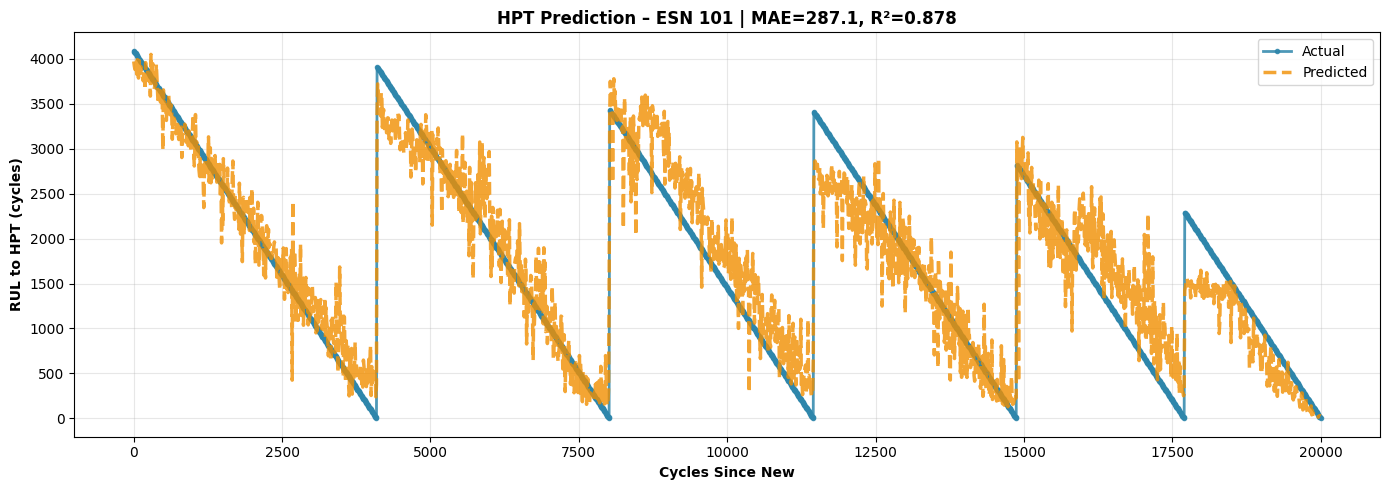

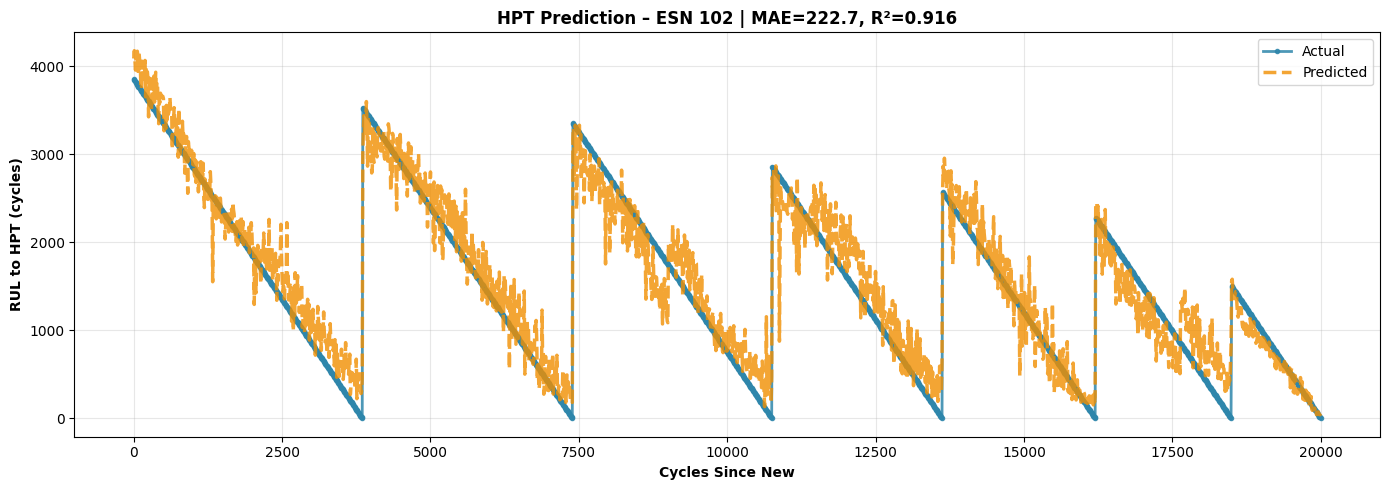

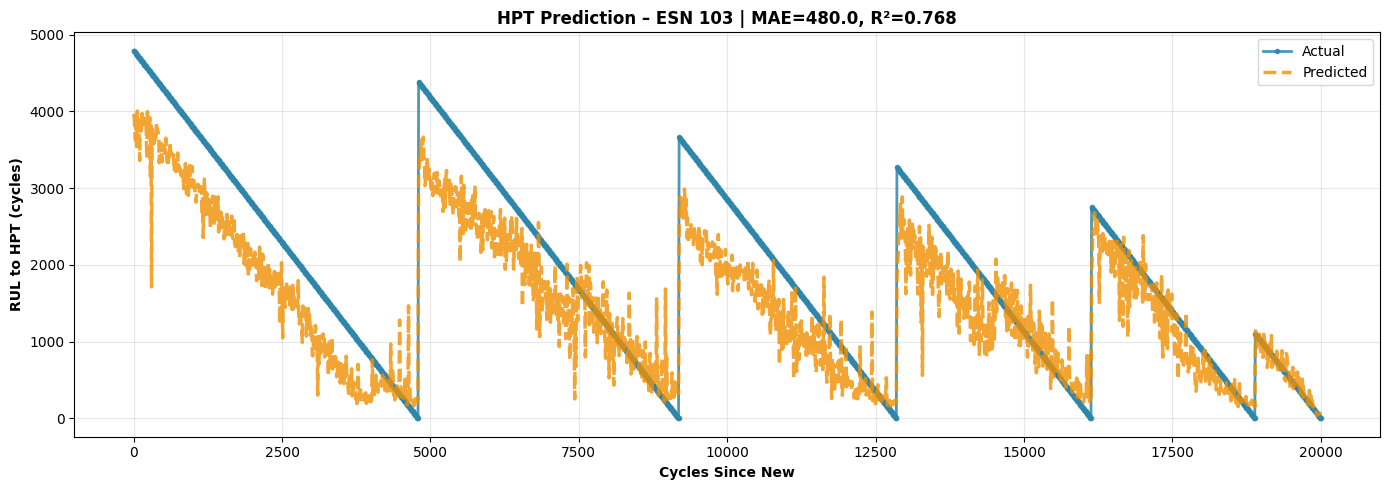

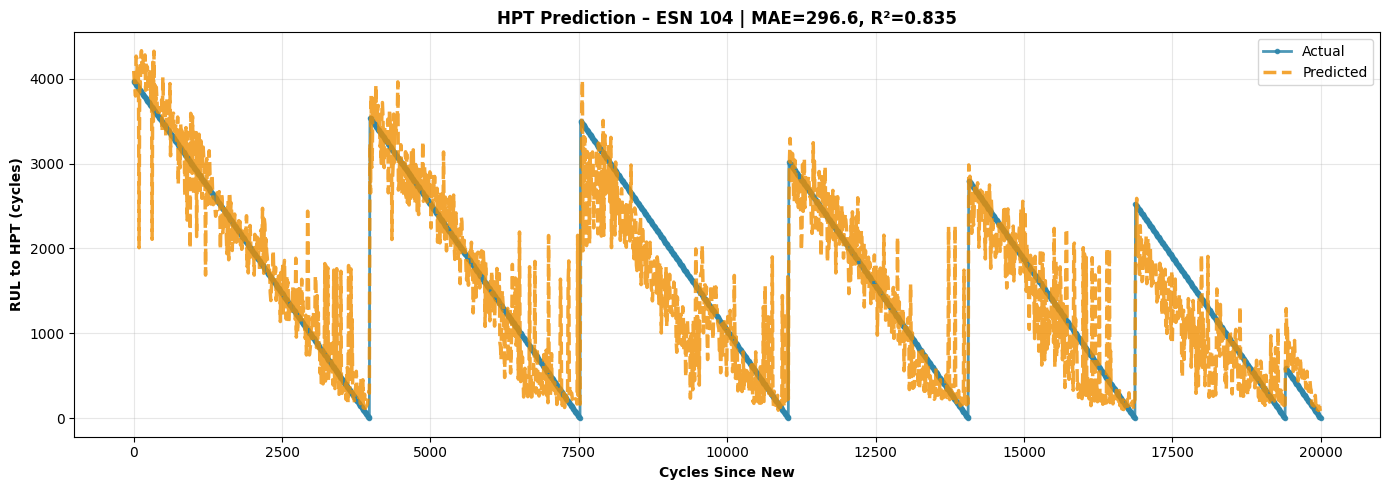

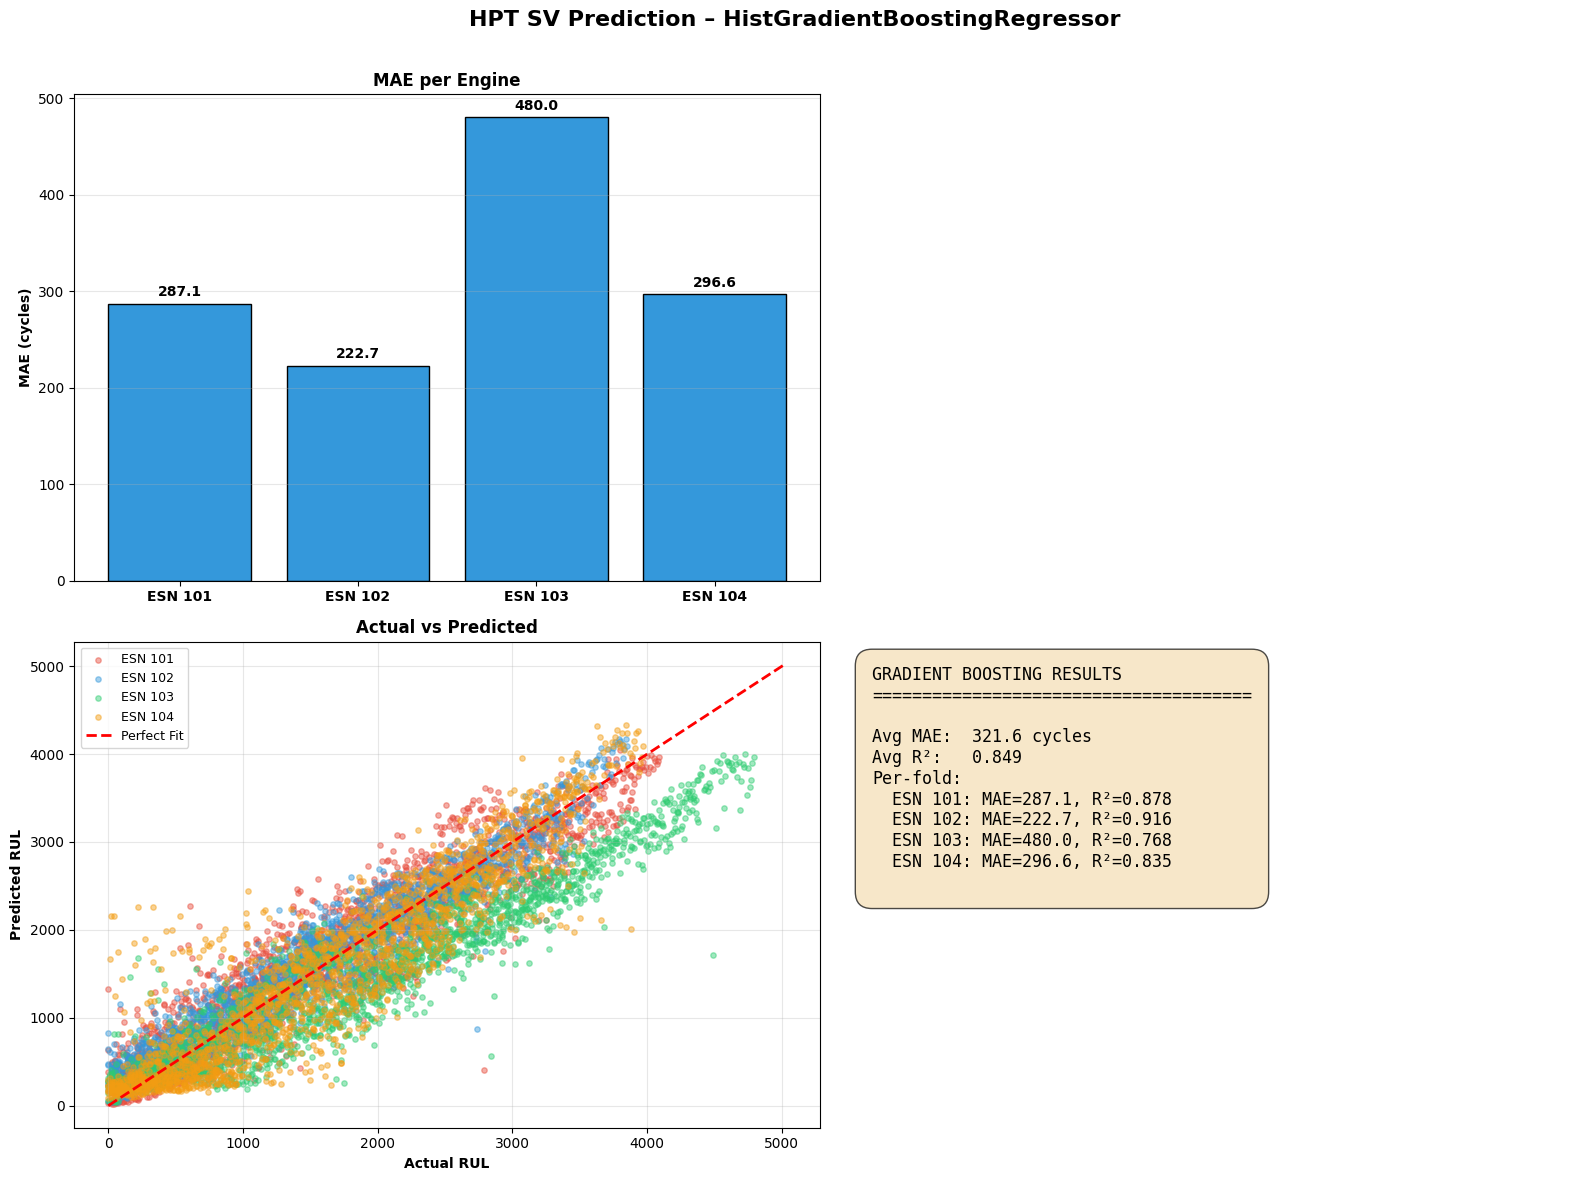


  ✓ Plots completati e salvati in -> HPT_results/
Numero feature: 67

--- PERFORMANCE MEDIE FINALI (TUNED) ---

--- PERFORMANCE MEDIE FINALI (TUNED) ---
MAE medio: 321.58
R2 medio:  0.849


In [27]:
# --------------------------------------------------
# MAIN
# --------------------------------------------------
def main():
    cfg = load_config("configs/config.yaml")
    # Caricamento (usa il tuo percorso file corretto)
    path = cfg['data']['train_clean_csv']
    df = pd.read_csv(path)
    
    print("Pre-processing...")
    df_cycle = aggregate_snapshots(df)
    df_final = add_engine_features(df_cycle)
    
    # Selezione Feature
    features = [c for c in df_final.columns if '_slope' in c or '_delta' in c]
    features.append('Cycles')
    target = 'Cycles_to_HPT_SV_first'
    
    # 1. TUNING: Trova la combinazione migliore di parametri\
    best_params = tune_hyperparameters(df_final, features, target)
    
    # 2. LOEO: Valuta il modello usando quei parametri
    res = train_loeo(df_final, features, target, best_params)

    plot_results(res, out_dir="HPT_results")

    print("Numero feature:", len(features))
    
    print("\n--- PERFORMANCE MEDIE FINALI (TUNED) ---")
    maes = [fr['mae'] for fr in res]
    r2s  = [fr['r2']  for fr in res]

    print("\n--- PERFORMANCE MEDIE FINALI (TUNED) ---")
    print(f"MAE medio: {np.mean(maes):.2f}")
    print(f"R2 medio:  {np.mean(r2s):.3f}")

if __name__ == "__main__":
    main()